## Carga y Preparación Básica

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")

df = pd.read_csv("..\Data\marketing_campaign_dataset.csv")
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  str    
 2   Campaign_Type     200000 non-null  str    
 3   Target_Audience   200000 non-null  str    
 4   Duration          200000 non-null  str    
 5   Channel_Used      200000 non-null  str    
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  str    
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  str    
 10  Language          200000 non-null  str    
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  str    
 15  Date              200000 non-null  str    
dtypes: float64(2), int64(4), str(10

In [3]:
df.describe()

,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,100000.500000,0.080070,5.002438,549.772030,5507.301520,5.494710
std,57735.171256,0.040602,1.734488,260.019056,2596.864286,2.872581
min,1.000000,0.010000,2.000000,100.000000,1000.000000,1.000000
25%,50000.750000,0.050000,3.500000,325.000000,3266.000000,3.000000
50%,100000.500000,0.080000,5.010000,550.000000,5517.500000,5.000000
75%,150000.250000,0.120000,6.510000,775.000000,7753.000000,8.000000
max,200000.000000,0.150000,8.000000,1000.000000,10000.000000,10.000000


In [4]:
df.isnull().sum()

Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

In [5]:
# Convertir 'Date' a formato datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convertir 'Acquisition_Cost' a numérico, eliminando símbolos de moneda y comas
df['Acquisition_Cost'] = (
    df['Acquisition_Cost']
    .replace('[\$,]', '', regex=True)  # elimina $ y comas
    .astype(float)
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Campaign_ID       200000 non-null  int64         
 1   Company           200000 non-null  str           
 2   Campaign_Type     200000 non-null  str           
 3   Target_Audience   200000 non-null  str           
 4   Duration          200000 non-null  str           
 5   Channel_Used      200000 non-null  str           
 6   Conversion_Rate   200000 non-null  float64       
 7   Acquisition_Cost  200000 non-null  float64       
 8   ROI               200000 non-null  float64       
 9   Location          200000 non-null  str           
 10  Language          200000 non-null  str           
 11  Clicks            200000 non-null  int64         
 12  Impressions       200000 non-null  int64         
 13  Engagement_Score  200000 non-null  int64         
 14  Customer_Segmen

In [6]:
# Verificar duplicados
df.duplicated().sum()

np.int64(0)

## Análisis Exploratorio (EDA)

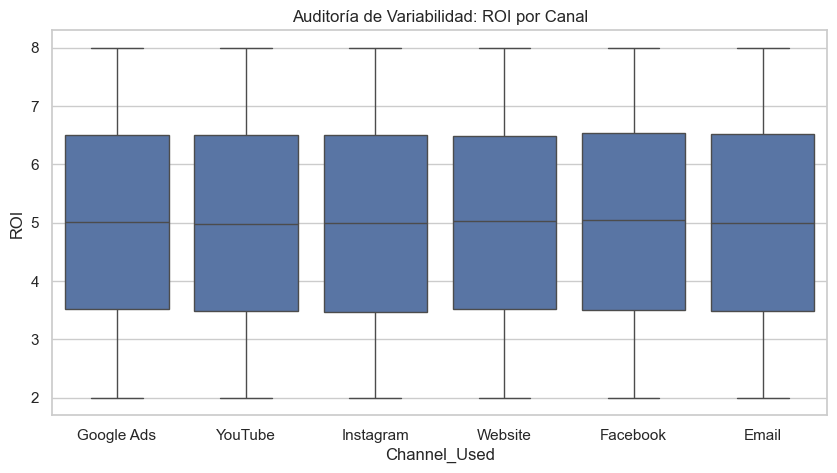

Desviación Estándar del ROI por Canal:
Channel_Used
Email         1.738349
Facebook      1.738050
Google Ads    1.733629
Instagram     1.739413
Website       1.725129
YouTube       1.732278
Name: ROI, dtype: float64


In [9]:
# Calcular Tasa de Clicks (CTR)
df['CTR'] = df['Clicks'] / df['Impressions']

# ¿Hay diferencias reales entre canales? 
# Si el ROI es casi idéntico en todos, el dataset es "plano" (ruido aleatorio).
plt.figure(figsize=(10, 5))
sns.boxplot(x='Channel_Used', y='ROI', data=df)
plt.title("Auditoría de Variabilidad: ROI por Canal")
plt.show()

print("Desviación Estándar del ROI por Canal:")
print(df.groupby('Channel_Used')['ROI'].std())

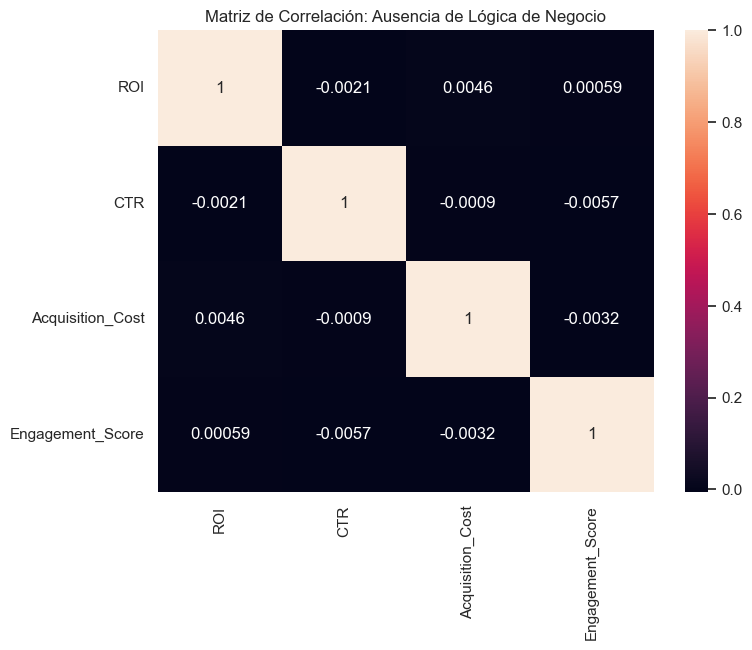

In [8]:
# Correlation Analysis
corr = df[['ROI', 'CTR', 'Acquisition_Cost', 'Engagement_Score']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Matriz de Correlación: Ausencia de Lógica de Negocio")
plt.show()

🚩 Hallazgos de la Auditoría (Data Audit Report)
Tras realizar un Análisis Exploratorio de Datos (EDA) profundo sobre el dataset original, se han detectado las siguientes anomalías que impiden un análisis de negocio fiable:

1. Baja Cardinalidad y Variabilidad: Las métricas de rendimiento (ROI, Tasa de Conversión) muestran distribuciones casi idénticas entre canales y segmentos de clientes. No hay "ganadores" ni "perdedores" claros, lo que sugiere una generación de datos puramente aleatoria.

2. Ausencia de Correlación Lógica: Se calculó la matriz de correlación y se detectó un valor de -0.0021 entre el CTR y el ROI. En un entorno de negocio real, el nivel de interacción inicial (clicks) tiene un impacto directo y proporcional en la rentabilidad. Un coeficiente tan cercano a cero demuestra estadísticamente que las variables son independientes y el dataset original es ruido sintético.

3. Métricas Estáticas: El costo de adquisición no varía según la saturación del canal o el tipo de audiencia, algo que no ocurre en plataformas como Google Ads o Facebook Ads.

Decisión: 
El dataset original es insuficiente para un análisis de optimización presupuestaria. Se procederá a utilizar el script data_simulator.py para inyectar reglas de negocio realistas (fatiga de anuncios, valor de vida del cliente por segmento y eficiencia por canal) para proceder con el análisis en el notebook 02_niche_discovery.ipynb.